### MACHINE LEARNING PROJECT OF MINIST DIGIT  DATASET

### Introduction

MNIST Digit Recognition is a machine learning project based on handwritten digit images ranging from 0 to 9. The dataset consists of grayscale images of digits, where each image is represented by pixel values. The main purpose of this project is to process and classify handwritten digits using machine learning techniques.


In [1]:

# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


Observation

The required Python libraries were imported successfully. These libraries are used for data handling, visualization, machine learning, and model evaluation.

In [33]:
# Load dataset

data = pd.read_csv("mnist_train.csv")

print("Dataset loaded successfully!")


Dataset loaded successfully!


In [ ]:
#show the rows and column
data.shape

(60000, 785)

In [ ]:
#first 5 rows
data.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Observation

The MNIST dataset contains handwritten digit images. Each image is represented using 784 pixel values corresponding to a 28×28 image.

In [9]:
# Display dataset information

print("Dataset Information:")
print(data.info())


print("\nColumn Names:")
print(data.columns[:10])

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB
None

Column Names:
Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9'], dtype='str')


Observation

The dataset contains one target column (label) and 784 pixel-feature columns. The pixel values represent the intensity of each pixel in the handwritten digit.

In [10]:
# Check missing values

missing_values = data.isnull().sum().sum()

print("Total Missing Values:", missing_values)

Total Missing Values: 0


Observation:The dataset does not contain missing values and no missing-value treatment is required.

In [11]:
# Separate target and features

X = data.drop("label", axis=1)
y = data["label"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (60000, 784)
Target Shape: (60000,)


Observation

The label column is the target variable containing digits from 0 to 9. The remaining 784 columns are used as input features.

In [12]:
# Display number of samples for each digit

print("Digit Distribution:")
print(y.value_counts().sort_index())

Digit Distribution:
label
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64


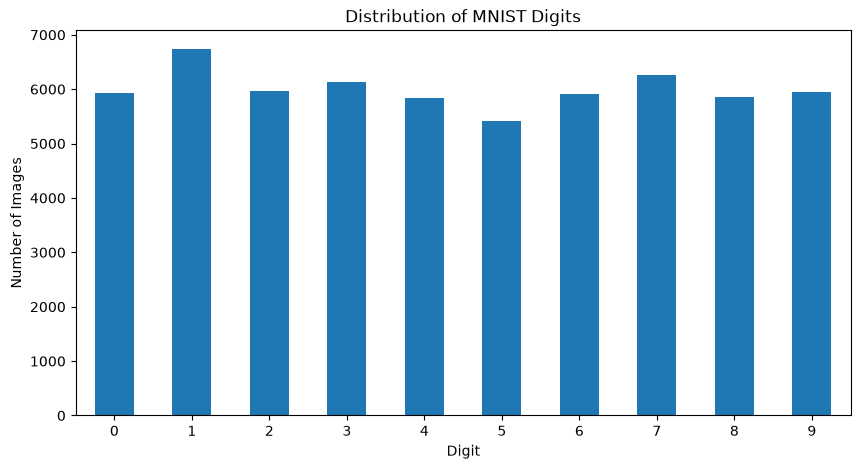

In [13]:
#Visulization
plt.figure(figsize=(10, 5))

y.value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of MNIST Digits")
plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.show()

Observation

The bar chart shows how many images are available for each digit from 0 to 9. This helps us understand the distribution of the target classes.

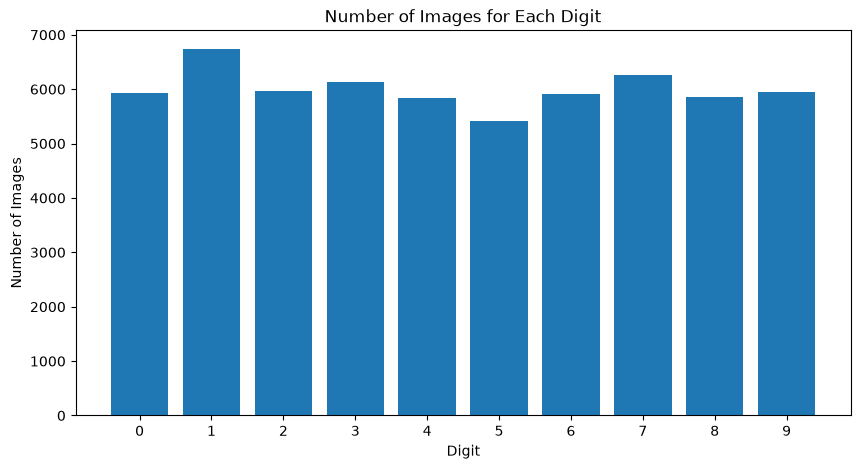

In [ ]:
#Digit Distribution Graph
plt.figure(figsize=(10, 5))

digit_counts = y.value_counts().sort_index()

plt.bar(digit_counts.index, digit_counts.values)

plt.title("Number of Images for Each Digit")
plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.xticks(range(10))

plt.show()

Observation

The graph shows the number of samples available for each digit from 0 to 9. It helps determine whether the dataset has a balanced distribution of digit classes.

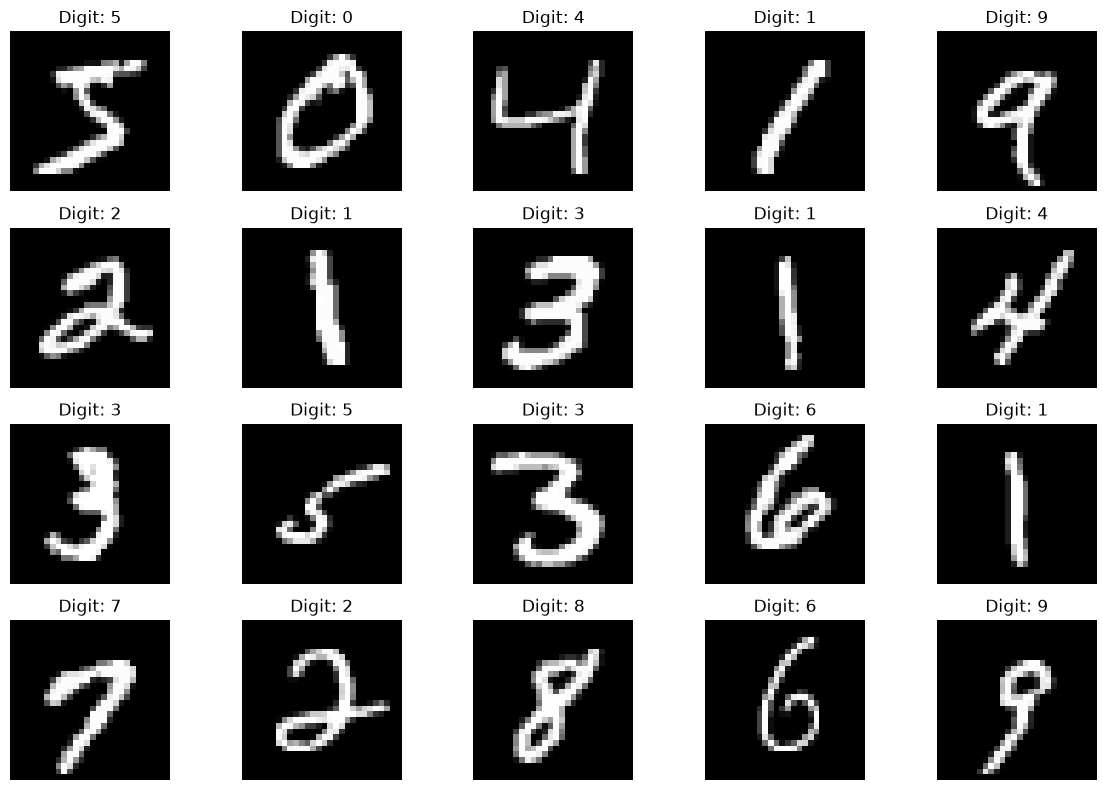

In [28]:
#Display Multiple Handwritten Digits
plt.figure(figsize=(12, 8))

for i in range(20):

    image = X.iloc[i].values.reshape(28, 28)

    plt.subplot(4, 5, i + 1)

    plt.imshow(image, cmap="gray")

    plt.title(f"Digit: {y.iloc[i]}")

    plt.axis("off")

plt.tight_layout()
plt.show()

Observation

The displayed images confirm that the dataset contains handwritten digits with different writing styles. Each image has a size of 28×28 pixels.

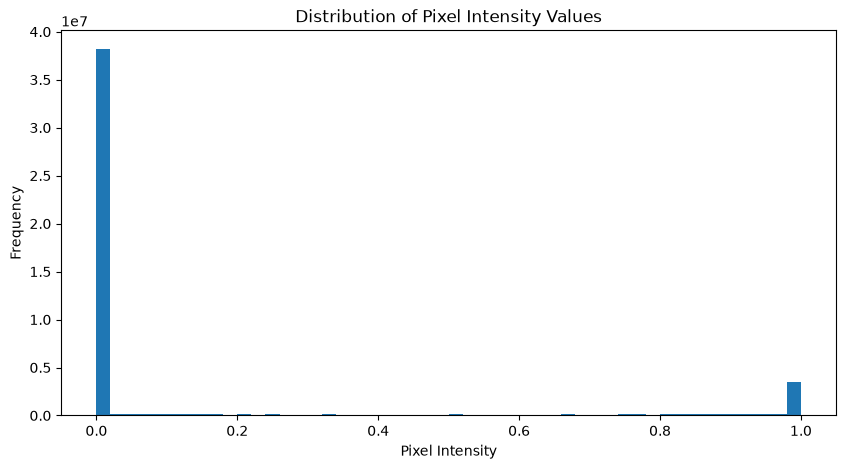

In [29]:
# Flatten all pixel values

pixel_values = X.values.flatten()

plt.figure(figsize=(10, 5))

plt.hist(
    pixel_values,
    bins=50
)

plt.title("Distribution of Pixel Intensity Values")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

Observation

The histogram shows the distribution of pixel intensity values. Most pixels are expected to have low intensity because large portions of handwritten digit images are background.

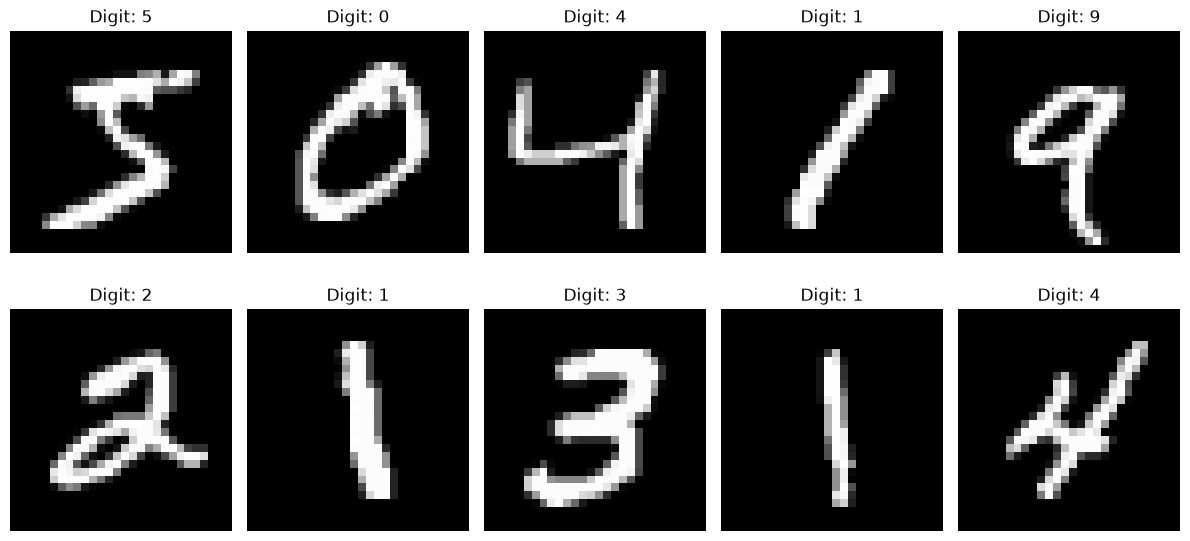

In [14]:
# Display first 10 handwritten digit images

plt.figure(figsize=(12, 6))

for i in range(10):

    image = X.iloc[i].values.reshape(28, 28)

    plt.subplot(2, 5, i + 1)

    plt.imshow(image, cmap="gray")

    plt.title(f"Digit: {y.iloc[i]}")

    plt.axis("off")

plt.tight_layout()
plt.show()

Observation

The pixel values are converted back into a 28×28 image so that the handwritten digits can be visually inspected.

In [15]:
# Normalize pixel values

X = X / 255.0

print("Minimum Pixel Value:", X.min().min())
print("Maximum Pixel Value:", X.max().max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


Observation

Pixel normalization scales the input values from 0–255 to 0–1. This makes the features easier for the machine-learning model to process.

In [16]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (48000, 784)
Testing Features: (12000, 784)
Training Labels: (48000,)
Testing Labels: (12000,)


Observation

The dataset has been divided into training and testing portions. The training data is used to learn digit patterns, while the testing data is used to evaluate the model on unseen examples.

In [17]:
#Train the Model
# Create SVM model

model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

print("Training SVM model...")

model.fit(X_train, y_train)

print("Model training completed!")

Training SVM model...
Model training completed!


Observation

The SVM model learns patterns from the handwritten digit images and learns to distinguish between the ten classes, 0 through 9.

In [18]:
# Make Prediction digits from test data

y_pred = model.predict(X_test)

print("Predictions completed!")

print("\nFirst 20 Predictions:")
print(y_pred[:20])

Predictions completed!

First 20 Predictions:
[7 7 3 5 6 9 6 6 7 2 0 5 6 7 0 4 0 6 8 4]


Observation

The trained model predicts a digit between 0 and 9 for every image in the test set.

In [19]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.9828333333333333
Accuracy Percentage: 98.28333333333333 %


Observation

The accuracy represents the percentage of test images that were classified correctly. A higher accuracy indicates that the model correctly recognizes more handwritten digits.

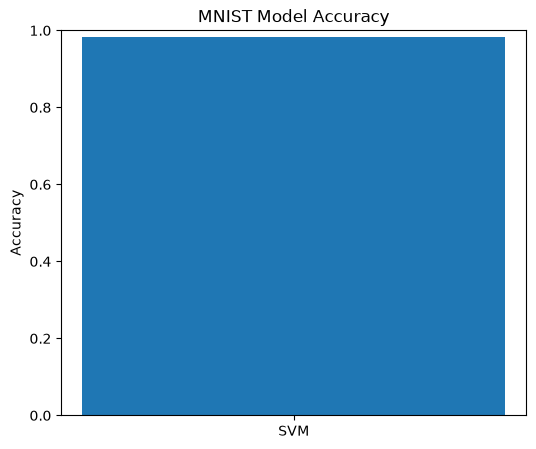

Model Accuracy: 98.28%


In [30]:
#Model Accuracy Graph
accuracy = accuracy_score(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

plt.bar(
    ["SVM"],
    [accuracy]
)

plt.title("MNIST Model Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Observation

The accuracy graph represents the overall percentage of test images correctly classified by the SVM model.

In [20]:
# Generate classification report

report = classification_report(
    y_test,
    y_pred
)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1185
           1       0.98      0.99      0.99      1348
           2       0.97      0.98      0.98      1192
           3       0.98      0.98      0.98      1226
           4       0.98      0.98      0.98      1168
           5       0.98      0.98      0.98      1084
           6       0.99      0.99      0.99      1184
           7       0.99      0.98      0.98      1253
           8       0.98      0.98      0.98      1170
           9       0.98      0.97      0.98      1190

    accuracy                           0.98     12000
   macro avg       0.98      0.98      0.98     12000
weighted avg       0.98      0.98      0.98     12000



Observation

The classification report provides detailed performance for each digit class. Precision, recall, and F1-score help us understand how well the model recognizes individual digits.

In [34]:
#2 model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest model...")

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

# Make predictions
rf_pred = rf_model.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")

# Classification report
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Training Random Forest model...
Random Forest training completed!
Random Forest Accuracy: 0.9665
Random Forest Accuracy: 96.65%

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1185
           1       0.97      0.98      0.98      1348
           2       0.95      0.97      0.96      1192
           3       0.96      0.95      0.95      1226
           4       0.97      0.97      0.97      1168
           5       0.96      0.96      0.96      1084
           6       0.98      0.98      0.98      1184
           7       0.98      0.96      0.97      1253
           8       0.95      0.95      0.95      1170
           9       0.95      0.95      0.95      1190

    accuracy                           0.97     12000
   macro avg       0.97      0.97      0.97     12000
weighted avg       0.97      0.97      0.97     12000



Observation:
The Random Forest model was successfully trained using the training dataset. It uses multiple decision trees to learn patterns from the handwritten digit images and classify digits from 0 to 9.

In [35]:
#Make prediction
rf_pred = rf_model.predict(X_test)

print("Predictions completed!")
print("First 20 Predictions:")
print(rf_pred[:20])

Predictions completed!
First 20 Predictions:
[9 7 3 5 6 9 6 6 7 2 0 5 6 7 0 4 0 6 8 4]


Observation:
The trained Random Forest model predicted the digit classes for the unseen test images. Each prediction represents one of the digits from 0 to 9.

In [36]:
#Calculate Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Accuracy: 0.9665
Random Forest Accuracy: 96.65%


Observation:
The accuracy shows the percentage of test images correctly classified by the Random Forest model. This value can be compared with the SVM accuracy to determine which model performed better on the same test dataset.

In [39]:
#Classification Report
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1185
           1       0.97      0.98      0.98      1348
           2       0.95      0.97      0.96      1192
           3       0.96      0.95      0.95      1226
           4       0.97      0.97      0.97      1168
           5       0.96      0.96      0.96      1084
           6       0.98      0.98      0.98      1184
           7       0.98      0.96      0.97      1253
           8       0.95      0.95      0.95      1170
           9       0.95      0.95      0.95      1190

    accuracy                           0.97     12000
   macro avg       0.97      0.97      0.97     12000
weighted avg       0.97      0.97      0.97     12000



Observation:
The classification report provides precision, recall, and F1-score for each digit class. These metrics help evaluate how effectively the Random Forest model recognizes individual digits.

In [37]:
#compare model
svm_accuracy = accuracy_score(y_test, y_pred)

print("SVM Accuracy:", svm_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

if svm_accuracy > rf_accuracy:
    print("SVM has higher accuracy.")
elif rf_accuracy > svm_accuracy:
    print("Random Forest has higher accuracy.")
else:
    print("Both models have the same accuracy.")

SVM Accuracy: 0.9828333333333333
Random Forest Accuracy: 0.9665
SVM has higher accuracy.


Observation:
The accuracy of SVM and Random Forest is compared using the same test dataset. The model with the higher actual test accuracy provides better accuracy for this particular experiment.

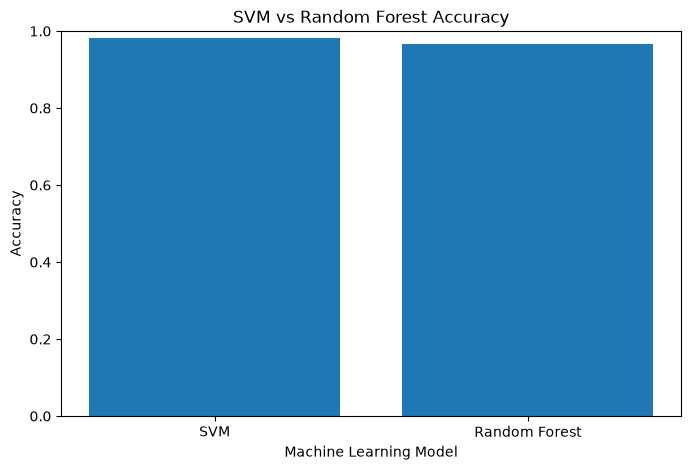

In [ ]:
#Accuracy Comarision Graph
models = ["SVM", "Random Forest"]
accuracies = [svm_accuracy, rf_accuracy]

plt.figure(figsize=(8, 5))

plt.bar(models, accuracies)

plt.title("SVM vs Random Forest Accuracy")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylDim(0, 1)

plt.show()

Observation:
The bar chart provides a visual comparison of the accuracy achieved by SVM and Random Forest. It makes the difference in model performance easier to understand.

In [21]:
# Generate confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1182    1    0    0    0    0    0    0    1    1]
 [   0 1337    5    2    1    1    0    2    0    0]
 [   3    3 1170    6    3    0    2    2    3    0]
 [   2    0    8 1198    0    6    0    1    9    2]
 [   1    3    3    0 1150    0    1    2    0    8]
 [   1    1    0    7    2 1062    6    0    3    2]
 [   7    1    0    0    3    5 1167    0    1    0]
 [   1    4   12    1    2    0    0 1224    1    8]
 [   3    4    4    2    2    4    1    1 1144    5]
 [   2    4    0    3    7    4    0    6    4 1160]]


<Figure size 1000x800 with 0 Axes>

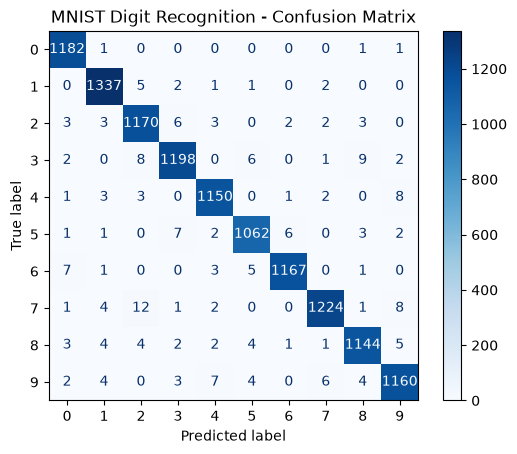

In [22]:
#Display confusion Matrix
plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("MNIST Digit Recognition - Confusion Matrix")

plt.show()

Observation

The confusion matrix shows the number of correct and incorrect predictions for every digit. The diagonal values represent correctly classified images, while the off-diagonal values represent misclassified digits.

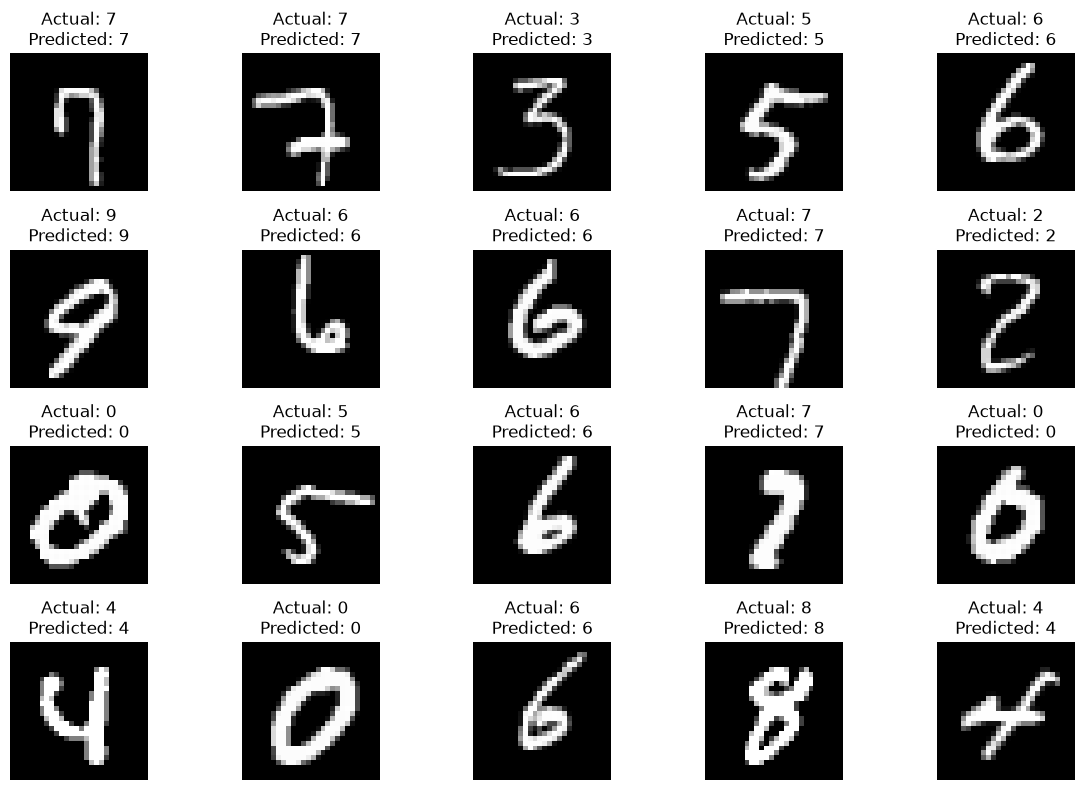

In [23]:
# Display actual and predicted digits

plt.figure(figsize=(12, 8))

for i in range(20):

    image = X_test.iloc[i].values.reshape(28, 28)

    plt.subplot(4, 5, i + 1)

    plt.imshow(image, cmap="gray")

    plt.title(
        f"Actual: {y_test.iloc[i]}\n"
        f"Predicted: {y_pred[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

Observation

The images allow us to visually compare the actual digit with the digit predicted by the model. Correct predictions should have matching actual and predicted labels.

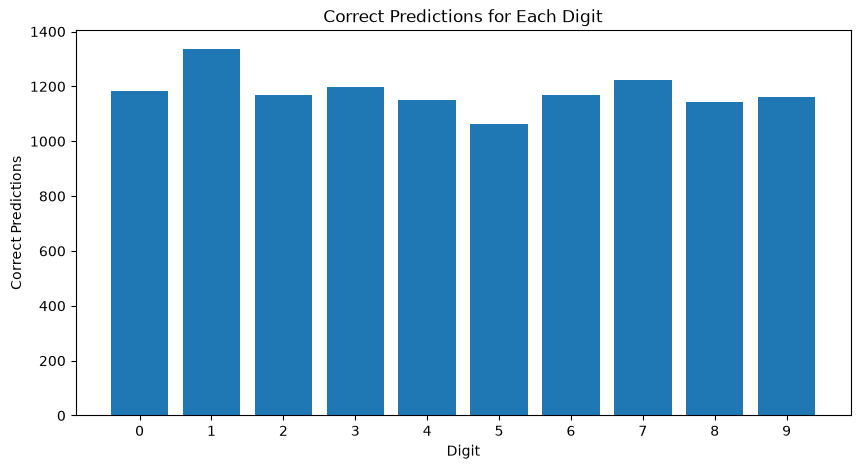

In [ ]:
# Calculate correct predictions for each digit

correct_per_digit = []

for digit in range(10):

    mask = y_test.values == digit

    correct = np.sum(
        y_pred[mask] == digit
    )

    correct_per_digit.append(correct)

plt.figure(figsize=(10, 5))

plt.bar(
    range(10),
    correct_per_digit
)
plt.title("Correct Predictions for Each Digit")
plt.xlabel("Digit")
plt.ylabel("Correct Predictions")
plt.xticks(range(10))
plt.show()

Observation

The graph shows the number of correctly classified images for each digit. It helps identify which digit classes were recognized more successfully.

In [24]:
# Find incorrect predictions

incorrect_indices = np.where(
    y_test.values != y_pred
)[0]

print("Total Test Images:", len(y_test))
print("Correct Predictions:", len(y_test) - len(incorrect_indices))
print("Incorrect Predictions:", len(incorrect_indices))

Total Test Images: 12000
Correct Predictions: 11794
Incorrect Predictions: 206


Observation

This identifies the images that the model classified incorrectly. These incorrectly classified images can be examined to understand which handwritten digits are difficult for the model.

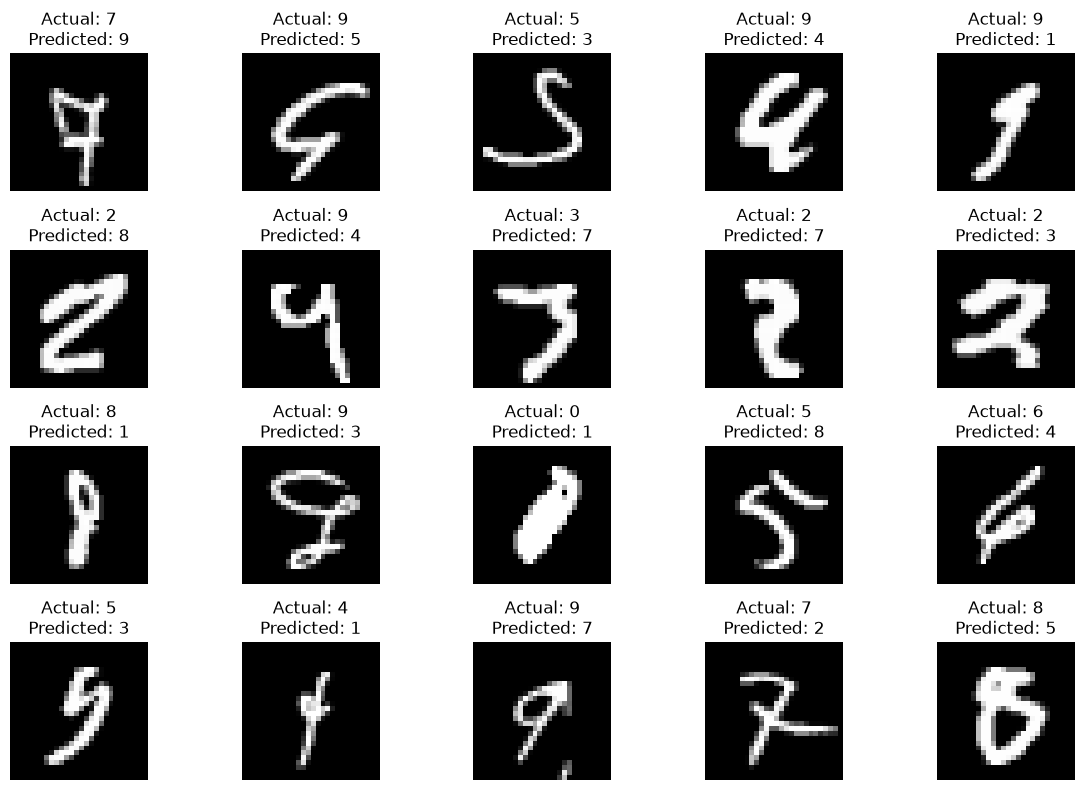

In [25]:
# Display incorrectly classified images

plt.figure(figsize=(12, 8))

for i, index in enumerate(incorrect_indices[:20]):

    image = X_test.iloc[index].values.reshape(28, 28)

    plt.subplot(4, 5, i + 1)

    plt.imshow(image, cmap="gray")

    plt.title(
        f"Actual: {y_test.iloc[index]}\n"
        f"Predicted: {y_pred[index]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

Observation

The incorrectly classified images show where the model has difficulty distinguishing similar handwritten digits.

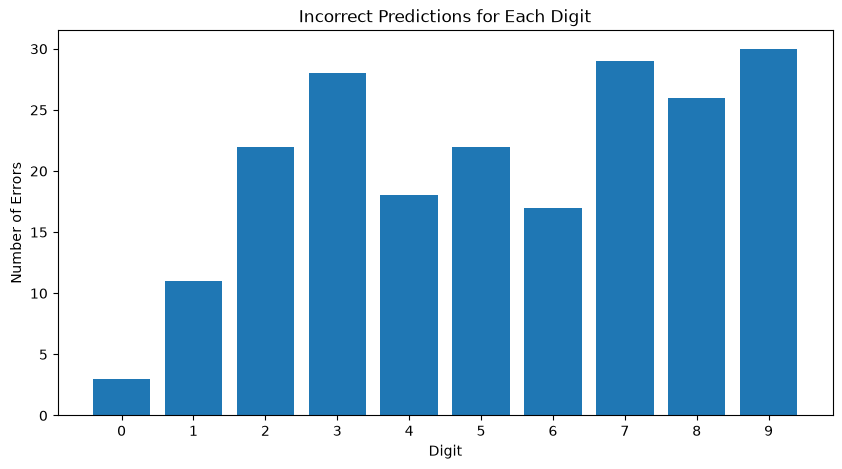

In [ ]:
# Calculate errors for each digit

error_per_digit = []

for digit in range(10):

    mask = y_test.values == digit

    errors = np.sum(
        y_pred[mask] != digit
    )

    error_per_digit.append(errors)

plt.figure(figsize=(10, 5))

plt.bar(
    range(10),
    error_per_digit
)
plt.title("Incorrect Predictions for Each Digit")
plt.xlabel("Digit")
plt.ylabel("Number of Errors")
plt.xticks(range(10))
plt.show()

Observation

The graph shows the number of classification errors for each digit. A lower error count indicates that the model made fewer mistakes for that class.

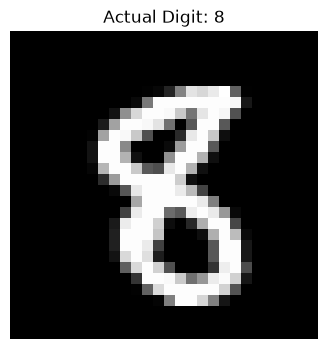

Predicted Digit: 8
Actual Digit: 8


In [ ]:
# Select one test image
index = 100
single_image = X_test.iloc[index].values.reshape(28, 28)

plt.figure(figsize=(4, 4))

plt.imshow(
    single_image,
    cmap="gray"
)

plt.title(
    f"Actual Digit: {y_test.iloc[index]}"
)
plt.axis("off")
plt.show()
# Predict the digit
prediction = model.predict(
    X_test.iloc[[index]]
)
print("Predicted Digit:", prediction[0])
print("Actual Digit:", y_test.iloc[index])

Observation

The trained model successfully predicts the class of an individual handwritten digit. The prediction can be compared with the actual label.